# scPoli校正流程 Python版

把`原始基因表达h5ad`和`cell×10 scPoli h5ad`合并，按Seurat代码逻辑做epithelial subset、Normalize、UMAP过滤、scPoli聚类、local purity过滤、marker DotPlot和统计输出。

该文件的输出都在：/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_mouse_scpoli

# import

In [3]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)

In [2]:
raw_h5ad="../../7_mapping_new_data/0511_rename_noIAISR/output_mouse/mouse_aggregated_counts_annot.h5ad"##只有小鼠数据 原始counts + annot,现在这个文件中的cell_type_level1是ground truth
scpoli_h5ad="../../7_mapping_new_data/0511_rename_noIAISR/output_mouse/level1_mouse_atlas_nogene.h5ad"### all human scpoli data without gene names, but with annotation
outdir="./output_mouse_scpoli/work_0513/"
counts_layer="rounded_corrected_counts"
original_celltype_col="cell_type_level1"##原始文件里的标签
os.makedirs(outdir,exist_ok=True)

In [3]:
#####读取文件 按 adata_scpoli 的细胞ID 对齐 adata_raw
adata_raw=sc.read_h5ad(raw_h5ad)
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
print(adata_raw)
print(adata_raw.obs_names)
print(adata_scpoli)
print(adata_scpoli.obs_names)

AnnData object with n_obs × n_vars = 572085 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE131776_5_UMAP', 'decontX_GSE131776_6_UMAP', 'decontX_GSE131776_7_UMAP', 'decontX_GSE131776_8_UMAP', 'decontX_GSE131776_9_UMAP', 'decontX_GSE141031_apoe

In [4]:
###得到共同的细胞
adata_raw.obs_names=adata_raw.obs_names.astype(str)
adata_scpoli.obs_names=adata_scpoli.obs_names.astype(str)
##保留原始barcode
adata_raw.obs["barcode_for_match"]=adata_raw.obs_names
adata_scpoli.obs["barcode_for_match"]=adata_scpoli.obs_names.str[:-2]
##用 sample + barcode 构建唯一ID
adata_raw.obs["match_id"]=adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
adata_scpoli.obs["match_id"]=adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
##如果sample仍不唯一，就改成 dataset + sample + barcode
if adata_raw.obs["match_id"].duplicated().sum()>0 or adata_scpoli.obs["match_id"].duplicated().sum()>0:
    adata_raw.obs["match_id"]=adata_raw.obs["dataset"].astype(str)+"__"+adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
    adata_scpoli.obs["match_id"]=adata_scpoli.obs["dataset"].astype(str)+"__"+adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
print("raw duplicated match_id:",adata_raw.obs["match_id"].duplicated().sum())
print("scpoli duplicated match_id:",adata_scpoli.obs["match_id"].duplicated().sum())
if adata_raw.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_raw match_id仍有重复，不能安全匹配")
if adata_scpoli.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_scpoli match_id仍有重复，不能安全匹配")
adata_raw.obs_names=adata_raw.obs["match_id"].astype(str)
adata_scpoli.obs_names=adata_scpoli.obs["match_id"].astype(str)

##空值填充为query
if "atlas_key" not in adata_scpoli.obs:
    adata_scpoli.obs["atlas_key"]="query"
else:
    adata_scpoli.obs["atlas_key"]=adata_scpoli.obs["atlas_key"].astype("object")
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].isna(),"atlas_key"]="query"
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].astype(str).isin(["","nan","None","NA"]),"atlas_key"]="query"

print(adata_scpoli.obs["atlas_key"].value_counts(dropna=False))
##以 scpoli 为准，从 raw 中取相同细胞
scp_ids=adata_scpoli.obs_names
missing=scp_ids[~scp_ids.isin(adata_raw.obs_names)]
print("scpoli cells:",len(scp_ids))
print("missing in raw:",len(missing))
if len(missing)>0:
    print(missing[:50].tolist())
    raise ValueError("有 scpoli 细胞在 raw 中找不到")
adata=adata_raw[scp_ids,:].copy()
adata_com_scpoli=adata_scpoli.copy()
assert np.all(adata.obs_names==adata_com_scpoli.obs_names)
print("aligned adata:",adata)
print("aligned adata_com_scpoli:",adata_com_scpoli)

raw duplicated match_id: 0
scpoli duplicated match_id: 0
atlas_key
query    566264
Name: count, dtype: int64
scpoli cells: 566264
missing in raw: 0
aligned adata: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UM

In [ ]:
# adata_query = adata[adata.obs['atlas_key'] == 'query']
# adata_query.obs['cell_type_level1'].value_counts()

In [ ]:
# adata.obs['atlas_key'].value_counts()

In [7]:
adata_com_scpoli.write(os.path.join(outdir, "mouse_scpoli_com.h5ad"))
adata.write(os.path.join(outdir, "mouse_raw_com.h5ad"))

In [8]:
adata_com_scpoli

AnnData object with n_obs × n_vars = 566264 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse', 'barcode_for_match', 'match_id'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [9]:
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE131776_5_UMAP', 'decontX_GSE131776_6_UMAP', 'decontX_GSE131776_7_UMAP', 'decontX_GSE131776_8_UMAP', 'decontX_GSE131776

In [10]:
##选择原始 counts 矩阵，并检查它像不像真正的原始计数
if counts_layer in adata.layers:
    adata.X=adata.layers[counts_layer].copy()
    print("use layer:",counts_layer)
else:
    print("layer not found,use adata.X:",counts_layer)
adata.layers["counts"]=adata.X.copy()
x=adata.layers["counts"]
v=x.data if sp.issparse(x) else np.ravel(x)
v=v[:min(len(v),1000000)]
print("counts min",np.min(v),"max",np.max(v),"integer-like",np.allclose(v,np.round(v)))

layer not found,use adata.X: rounded_corrected_counts
counts min 1 max 18798 integer-like True


In [ ]:
#####添加需要的obs
run_tag="precorrect"
for c in ["leiden","cell_type_pred","cell_type_uncert","query","cell_type_pred_ref","cell_type_level1_human","atlas_key"]:
    if c in adata_com_scpoli.obs:
        adata.obs[c]=adata_com_scpoli.obs[c].values
        print("+obs",c)
X=adata_com_scpoli.X.toarray() if sp.issparse(adata_com_scpoli.X) else np.asarray(adata_com_scpoli.X)
adata.obsm["X_scPoli"]=X
if "X_umap" in adata_com_scpoli.obsm:
    adata.obsm["X_umap"]=np.asarray(adata_com_scpoli.obsm["X_umap"])
print("X_scPoli",adata.obsm["X_scPoli"].shape)
print("X_umap",adata.obsm["X_umap"].shape if "X_umap" in adata.obsm else None)
adata.write(os.path.join(outdir,f"mouse_raw_counts_scpoli_{run_tag}.h5ad"))

+obs leiden
+obs cell_type_pred
+obs cell_type_uncert
+obs query
+obs cell_type_pred_ref
+obs atlas_key
X_scPoli (566264, 10)
X_umap (566264, 2)


In [12]:
##合并后先画一张全体细胞的 UMAP，检查 cell_type_pred 是否正常
if "X_umap" in adata.obsm and "cell_type_pred" in adata.obs:
    sc.pl.umap(adata,color="cell_type_pred",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"umap_cell_type_pred_full.pdf"),bbox_inches="tight")
    plt.close()
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'deco

In [13]:
adata.obs['cell_type_level1'].value_counts()

cell_type_level1
Fibroblast               126893
Smooth muscle cell       117643
Macrophage               103859
T cell                    71041
Neutrophil                56877
B cell                    28531
Endothelial cell          26425
Natural killer cell       10557
Dendritic cell             7402
Erythrocyte/Erythroid      7368
Basophil                   6134
Monocyte                   2057
Pericyte                   1293
Mast cell                   184
Name: count, dtype: int64

# mac/mono/neu

In [56]:
outdir="./output_mouse_scpoli/work_0513/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [15]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/mac_mono_neu/"

In [16]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [17]:
mac_mono_neu = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Macrophage", "Monocyte", "Neutrophil"],
    outdir=outdir,
    prefix="mac_mono_neu",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Macrophage', 'Monocyte', 'Neutrophil']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UM

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:01)
lognorm min 0.22429448 max 9.210441 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Macrophage    103859
Neutrophil     56877
Monocyte        2057
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 162793 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/mac_mono_neu/umap_mac_mono_neu_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/mac_mono_neu/umap_mac_mono_neu_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/mac_mono_neu/umap_mac_mono_neu_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     6930
1     5618
2     5201
3     5188
4     5165
5     5050
6     4513
7     4473
8     4461
9     4366
10    4347
11    4322
12    4273
13    4226
14    4131
15    4000
16    3989
17    3942
18    3918
19    3848
20    3682
21    3673
22    3521
23    3384
24    3370
25    3357
26    3229
27    3229
28    3225
29    3131
30    3024
31    2977
32    2977
33    2903
34    2805
35    2717
36    2615
37    2506
38    2288
39    2118
40    1929
41    1886
42    1724
43    1657
44    1468
45    1437
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/mac_mono_neu/mac_mono_neu_scPoli_recluster_umap.h5ad


In [7]:
outdir="./output_mouse_scpoli/work_0513/mac_mono_neu/"
label_col = "cell_type_pred"
cluster_key = "leiden_scpoli_res3"
work = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 162793 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131

In [8]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [9]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "mac_mono_neu_cluster_correction_summary.csv"))

         major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                               
0        Macrophage         0.959740          Pericyte           0.673160     6930           Uncertain
1        Macrophage         1.000000        Macrophage           0.650943     5618          Macrophage
2        Macrophage         0.853297          Monocyte           0.489521     5201           Uncertain
3        Neutrophil         0.969160          Monocyte           0.892444     5188           Uncertain
4        Macrophage         1.000000          Pericyte           0.644918     5165           Uncertain
5        Macrophage         1.000000        Macrophage           0.638218     5050          Macrophage
6        Neutrophil         0.853977          Pericyte           0.351208     4513           Uncertain
7        Macrophage         0.465683          Monocyte           0.812877

In [18]:
corrected_annotation = {
    "0": "Macrophage",
    "1": "Macrophage",
    "2": "Monocyte",
    "3": "Neutrophil",
    "4": "Macrophage",
    "5": "Macrophage",
    "6": "Macrophage",
    "7": "Monocyte",
    "8": "Macrophage",
    "9": "Macrophage",
    "10": "Macrophage",
    "11": "Macrophage",
    "12": "Macrophage",
    "13": "Macrophage",
    "14": "Macrophage",
    "15": "Macrophage",
    "16": "Macrophage",
    "17": "Macrophage",
    "18": "Neutrophil",
    "19": "Macrophage",
    "20": "Macrophage",
    "21": "Monocyte",
    "22": "Neutrophil",
    "23": "Macrophage",
    "24": "Macrophage",
    "25": "Monocyte",
    "26": "Macrophage",
    "27": "Neutrophil",
    "28": "Macrophage",
    "29": "undefine",
    "30": "Macrophage",
    "31": "Macrophage",
    "32": "Macrophage",
    "33": "Macrophage",
    "34": "Macrophage",
    "35": "Macrophage",
    "36": "Macrophage",
    "37": "Macrophage",
    "38": "Macrophage",
    "39": "Macrophage",
    "40": "Macrophage",
    "41": "Macrophage",
    "42": "Macrophage",
    "43": "Macrophage",
    "44": "Macrophage",
    "45": "Macrophage"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage    127102
Monocyte       16704
Neutrophil     15856
undefine        3131
Name: count, dtype: int64


In [20]:
work.write_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))

In [19]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cell_type_level1_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_dataset_after_correction4.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [21]:
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage    127102
Monocyte       16704
Neutrophil     15856
undefine        3131
Name: count, dtype: int64


# smc/fibro

In [3]:
outdir="./output_mouse_scpoli/work_0513/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [15]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/smc_fibro"

In [5]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [6]:
smc_fibro = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Smooth muscle cell", "Fibroblast"],
    outdir=outdir,
    prefix="smc_fibro",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Smooth muscle cell', 'Fibroblast']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:03)
lognorm min 0.24512248 max 8.502358 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Fibroblast            126893
Smooth muscle cell    117643
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 244536 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    u

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/smc_fibro/umap_smc_fibro_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/smc_fibro/umap_smc_fibro_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/smc_fibro/umap_smc_fibro_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     7764
1     7668
2     7446
3     6839
4     6690
5     6607
6     6537
7     6516
8     6508
9     6465
10    6442
11    6362
12    6334
13    6297
14    6136
15    5968
16    5931
17    5693
18    5689
19    5618
20    5616
21    5580
22    5507
23    5467
24    5362
25    5076
26    4987
27    4966
28    4503
29    4503
30    4365
31    4322
32    4213
33    4201
34    3989
35    3934
36    3919
37    3658
38    3554
39    3437
40    3168
41    3013
42    2839
43    2702
44    2555
45    2482
46    2366
47    1795
48    1538
49    1072
50     337
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/smc_fibro/smc_fibro_scPoli_recluster_umap.h5ad


In [16]:
outdir="./output_mouse_scpoli/work_0513/smc_fibro"
work = sc.read_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 244536 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131

In [19]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
    'Pericyte_2': ['Notch3', 'Pdgfrb', 'Rgs5', 'Cspg4', 'Kcnj8', 'Abcc9'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [20]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "smc_fibro_cluster_correction_summary.csv"))

                 major_pred  major_pred_frac        major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                         
0        Smooth muscle cell         1.000000  Smooth muscle cell           0.916924     7764  Smooth muscle cell
1        Smooth muscle cell         1.000000  Smooth muscle cell           0.954486     7668  Smooth muscle cell
2                Fibroblast         1.000000          Fibroblast           0.947891     7446          Fibroblast
3        Smooth muscle cell         0.936540  Smooth muscle cell           0.934786     6839  Smooth muscle cell
4        Smooth muscle cell         1.000000  Smooth muscle cell           0.586099     6690  Smooth muscle cell
5                Fibroblast         1.000000          Fibroblast           0.897987     6607          Fibroblast
6                Fibroblast         0.999847          Fibroblast           0.856203     6537    

In [21]:
corrected_annotation = {
    "0": "Smooth muscle cell",
    "1": "Smooth muscle cell",
    "2": "Fibroblast",
    "3": "Smooth muscle cell",
    "4": "Smooth muscle cell",
    "5": "Fibroblast",
    "6": "Fibroblast",
    "7": "Fibroblast",
    "8": "Fibroblast",
    "9": "Smooth muscle cell",
    "10": "Fibroblast",
    "11": "Smooth muscle cell",
    "12": "Smooth muscle cell",
    "13": "Fibroblast",
    "14": "Smooth muscle cell",
    "15": "Smooth muscle cell",
    "16": "Smooth muscle cell",
    "17": "Fibroblast",
    "18": "Smooth muscle cell",
    "19": "Smooth muscle cell",
    "20": "Smooth muscle cell",
    "21": "Smooth muscle cell",
    "22": "Smooth muscle cell",
    "23": "Fibroblast",
    "24": "Fibroblast",
    "25": "Fibroblast",
    "26": "Fibroblast",
    "27": "Smooth muscle cell",
    "28": "Fibroblast",
    "29": "Fibroblast",
    "30": "Fibroblast",
    "31": "Fibroblast",
    "32": "Fibroblast",
    "33": "Fibroblast",
    "34": "Fibroblast",
    "35": "Smooth muscle cell",
    "36": "Smooth muscle cell",
    "37": "Smooth muscle cell",
    "38": "Smooth muscle cell",
    "39": "Fibroblast",
    "40": "Smooth muscle cell",
    "41": "Smooth muscle cell",
    "42": "Fibroblast",
    "43": "Fibroblast",
    "44": "Smooth muscle cell",
    "45": "Smooth muscle cell",
    "46": "Fibroblast",
    "47": "Smooth muscle cell",
    "48": "Fibroblast",
    "49": "Smooth muscle cell",
    "50": "Neutrophil",
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Smooth muscle cell    128283
Fibroblast            115916
Neutrophil               337
Name: count, dtype: int64


In [22]:
work.write_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap_corrected.h5ad"))

In [23]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_smc_fib_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_smc_fib_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_smc_fib_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bo

# T cell

In [ ]:
# adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
# adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [24]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/tc"

In [31]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [32]:
tc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["T cell"],
    outdir=outdir,
    prefix="tc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['T cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:05)
lognorm min 0.22213814 max 8.075671 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
T cell    71041
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 71041 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli', 'X_umap',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/tc/umap_tc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/tc/umap_tc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/tc/umap_tc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     2826
1     2781
2     2637
3     2488
4     2384
5     2294
6     2274
7     2192
8     2151
9     2142
10    2116
11    2081
12    2074
13    2033
14    2016
15    1991
16    1983
17    1934
18    1919
19    1842
20    1827
21    1788
22    1788
23    1765
24    1720
25    1681
26    1584
27    1562
28    1557
29    1492
30    1472
31    1373
32    1278
33    1174
34    1134
35    1111
36     987
37     894
38     696
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/tc/tc_scPoli_recluster_umap.h5ad


In [25]:
outdir="./output_mouse_scpoli/work_0513/tc"
work = sc.read_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 71041 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [26]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [27]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "tc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           T cell              1.0       T cell           0.883581     2826              T cell
1           T cell              1.0       T cell           0.752967     2781              T cell
2           T cell              1.0       T cell           0.552522     2637              T cell
3           T cell              1.0       T cell           0.862540     2488              T cell
4           T cell              1.0       T cell           0.581795     2384              T cell
5           T cell              1.0       T cell           0.908893     2294              T cell
6           T cell              1.0       T cell           0.744063     2274              T cell
7           T cell              1.0       T cell           0.695255     2192              T cell
8           T cell            

In [28]:
corrected_annotation = {
    "38" : "Neutrophil"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
T cell        70345
Neutrophil      696
Name: count, dtype: int64


In [29]:
work.write_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap_corrected.h5ad"))

In [30]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_tc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_tc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_tc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_tc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# ECs

In [32]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/ec"

In [22]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [ ]:
ec = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Endothelial cell"],
    outdir=outdir,
    prefix="ec",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Endothelial cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:00)
lognorm min 0.35060126 max 8.470931 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Endothelial cell    26425
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 26425 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/ec/umap_ec_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/ec/umap_ec_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/ec/umap_ec_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1064
1     1052
2     1036
3     1006
4      970
5      930
6      913
7      873
8      868
9      830
10     829
11     796
12     793
13     784
14     776
15     771
16     766
17     763
18     727
19     720
20     687
21     680
22     672
23     666
24     653
25     634
26     610
27     606
28     605
29     560
30     560
31     492
32     475
33     452
34     423
35     383
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/ec/ec_scPoli_recluster_umap.h5ad


In [33]:
outdir="./output_mouse_scpoli/work_0513/ec"
work = sc.read_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 26425 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [34]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [35]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "ec_cluster_correction_summary.csv"))

               major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                     
0        Endothelial cell              1.0  Endothelial cell           0.915414     1064    Endothelial cell
1        Endothelial cell              1.0  Endothelial cell           0.852662     1052    Endothelial cell
2        Endothelial cell              1.0  Endothelial cell           0.992278     1036    Endothelial cell
3        Endothelial cell              1.0  Endothelial cell           0.882704     1006    Endothelial cell
4        Endothelial cell              1.0  Endothelial cell           0.994845      970    Endothelial cell
5        Endothelial cell              1.0  Endothelial cell           0.995699      930    Endothelial cell
6        Endothelial cell              1.0  Endothelial cell           0.791895      913    Endothelial cell
7        Endothelia

In [36]:
corrected_annotation = {
 
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Endothelial cell    26425
Name: count, dtype: int64


In [37]:
work.write_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap_corrected.h5ad"))

In [38]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_ec_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_ec_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_ec_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_ec_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# NK

In [39]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/nk"

In [25]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [26]:
nk = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Natural killer cell"],
    outdir=outdir,
    prefix="nk",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Natural killer cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/nk/umap_nk_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/nk/umap_nk_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/nk/umap_nk_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     565
1     529
2     483
3     467
4     448
5     409
6     409
7     390
8     390
9     383
10    367
11    360
12    350
13    345
14    342
15    330
16    313
17    311
18    295
19    294
20    288
21    279
22    271
23    267
24    261
25    250
26    242
27    229
28    202
29    169
30    156
31     78
32     44
33     41
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/nk/nk_scPoli_recluster_umap.h5ad


In [40]:
outdir="./output_mouse_scpoli/work_0513/nk"
work = sc.read_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 10557 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [41]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [42]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "nk_cluster_correction_summary.csv"))

                  major_pred  major_pred_frac         major_marker  major_marker_frac  n_cells  cluster_label_clean
cluster                                                                                                            
0        Natural killer cell              1.0  Natural killer cell           0.991150      565  Natural killer cell
1        Natural killer cell              1.0  Natural killer cell           0.986767      529  Natural killer cell
2        Natural killer cell              1.0  Natural killer cell           0.805383      483  Natural killer cell
3        Natural killer cell              1.0  Natural killer cell           0.526767      467  Natural killer cell
4        Natural killer cell              1.0               T cell           0.560268      448            Uncertain
5        Natural killer cell              1.0               T cell           0.564792      409            Uncertain
6        Natural killer cell              1.0  Natural killer cell      

In [43]:
corrected_annotation = {
    "2": "T cell",
    "3": "T cell",
    "4": "T cell",
    "5": "T cell",
    "7": "T cell",
    "8": "T cell",
    "11": "T cell",
    "12": "T cell",
    "13": "T cell",
    "19": "T cell",
    "23": "T cell",
    "27": "T cell",
    "29": "T cell",
    "30": "T cell",
    "31": "T cell",
    "32": "B cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Natural killer cell    5678
T cell                 4835
B cell                   44
Name: count, dtype: int64


In [44]:
work.write_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap_corrected.h5ad"))


In [45]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_nk_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_nk_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_nk_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_nk_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# B cells

In [46]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/bc"

In [28]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [29]:
bc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["B cell"],
    outdir=outdir,
    prefix="bc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['B cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:00)
lognorm min 0.18052614 max 8.6665535 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
B cell    28531
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 28531 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli', 'X_umap'

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/bc/umap_bc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/bc/umap_bc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/bc/umap_bc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1323
1     1172
2     1146
3     1113
4     1049
5     1023
6      982
7      975
8      974
9      952
10     947
11     938
12     934
13     929
14     857
15     849
16     837
17     826
18     822
19     822
20     822
21     817
22     810
23     787
24     771
25     702
26     628
27     622
28     618
29     603
30     543
31     496
32     319
33     205
34     194
35     124
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/bc/bc_scPoli_recluster_umap.h5ad


In [47]:
outdir="./output_mouse_scpoli/work_0513/bc"
work = sc.read_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 28531 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [48]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [49]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "bc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           B cell              1.0       B cell           0.988662     1323              B cell
1           B cell              1.0       B cell           0.958191     1172              B cell
2           B cell              1.0       B cell           0.911867     1146              B cell
3           B cell              1.0       B cell           0.885894     1113              B cell
4           B cell              1.0       B cell           0.988561     1049              B cell
5           B cell              1.0       B cell           0.979472     1023              B cell
6           B cell              1.0       B cell           0.966395      982              B cell
7           B cell              1.0       B cell           0.971282      975              B cell
8           B cell            

In [50]:
corrected_annotation = {
    "18": "T cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
B cell    27709
T cell      822
Name: count, dtype: int64


In [51]:
work.write_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap_corrected.h5ad"))

In [52]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_bc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_bc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_bc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_bc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# Basophil 

In [53]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse_scpoli/work_0513/Basophil"

In [54]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [57]:
outdir="./output_mouse_scpoli/work_0513/Basophil"
Basophil = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Basophil"],
    outdir=outdir,
    prefix="Basophil",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Basophil']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UM

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:19)
running Leiden clustering
    finished (0:00:24)
computing UMAP
    finished (0:00:20)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/Basophil/umap_Basophil_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/Basophil/umap_Basophil_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse_scpoli/work_0513/Basophil/umap_Basophil_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     422
1     374
2     350
3     322
4     303
5     287
6     285
7     284
8     283
9     281
10    250
11    220
12    209
13    196
14    196
15    194
16    193
17    188
18    181
19    176
20    176
21    159
22    142
23    140
24    130
25    108
26     85
Name: count, dtype: int64
Saved to: ./output_mouse_scpoli/work_0513/Basophil/Basophil_scPoli_recluster_umap.h5ad


In [58]:
work = sc.read_h5ad(os.path.join(outdir, "Basophil_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 6134 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE13177

In [59]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22']
T cell ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3']
Natural killer cell ['Nkg7', 'Xcl1', 'Ctsw', 'Cd160', 'Fcgr3', 'Prf1']
Dendritic cell ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1']
Macrophage ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163']
Monocyte ['S100a8', 'S100a9', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14']
Mast cell ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1']
Erythrocyte/Erythroid ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2']
Neutrophil ['Nampt', 'Ifitm2', 'G0s2', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp']
Basophil ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20']
Endothelial cell ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [60]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "Basophil_cluster_correction_summary.csv"))

        major_pred  major_pred_frac           major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                   
0         Basophil              1.0             Fibroblast           0.291469      422           Uncertain
1         Basophil              1.0  Erythrocyte/Erythroid           0.165775      374           Uncertain
2         Basophil              1.0                 T cell           0.457143      350           Uncertain
3         Basophil              1.0                 T cell           0.397516      322           Uncertain
4         Basophil              1.0               Pericyte           0.640264      303           Uncertain
5         Basophil              1.0       Endothelial cell           0.477352      287           Uncertain
6         Basophil              1.0       Endothelial cell           0.435088      285           Uncertain
7         Basophil              1.0  

In [61]:
corrected_annotation = {
     "0": 'Macrophage',
     "1": 'Macrophage',
     "2": 'Basophil',
     "3": 'Basophil',
     "4": 'undefine',
     "5": 'Macrophage',
     "6": 'Endothelial cell',
     "7": 'Basophil',
     "8": 'Neutrophil',
     "9": 'T cell',
     "10": 'Erythrocyte/Erythroid',
     "11": 'undefine',
     "12": 'undefine',
     "13": 'Macrophage',
     "14": 'undefine',
     "15": 'B cell',
     "16": 'undefine',
     "17": 'undefine',
     "18": 'Neutrophil',
     "19": 'Neutrophil',
     "20": 'Neutrophil',
     "21": 'Basophil',
     "22": 'B cell',
     "23": 'undefine',
     "24": 'Erythrocyte/Erythroid',
     "25": 'undefine',
     "26": 'T cell',
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
undefine                 1557
Macrophage               1279
Basophil                 1115
Neutrophil                816
Erythrocyte/Erythroid     380
T cell                    366
B cell                    336
Endothelial cell          285
Name: count, dtype: int64


In [62]:
work.write_h5ad(os.path.join(outdir, "Basophil_scPoli_recluster_umap_corrected.h5ad"))

In [63]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_Basophil_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_Basophil_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_Basophil_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [1]:
######还有mast cell,先不做

# 合并

In [4]:
outdir="./output_mouse_scpoli/work_0513/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [5]:
adata.obs["cell_type_level1"].value_counts()

cell_type_level1
Fibroblast               126893
Smooth muscle cell       117643
Macrophage               103859
T cell                    71041
Neutrophil                56877
B cell                    28531
Endothelial cell          26425
Natural killer cell       10557
Dendritic cell             7402
Erythrocyte/Erythroid      7368
Basophil                   6134
Monocyte                   2057
Pericyte                   1293
Mast cell                   184
Name: count, dtype: int64

In [2]:
outdir="./output_mouse_scpoli/work_0513/"
adata_bc = sc.read_h5ad(os.path.join(outdir, "bc/bc_scPoli_recluster_umap_corrected.h5ad"))
adata_nk = sc.read_h5ad(os.path.join(outdir, "nk/nk_scPoli_recluster_umap_corrected.h5ad"))
adata_mac_mono_neu = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu/mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))
adata_smc_fibro = sc.read_h5ad(os.path.join(outdir, "smc_fibro/smc_fibro_scPoli_recluster_umap_corrected.h5ad"))
adata_tc = sc.read_h5ad(os.path.join(outdir, "tc/tc_scPoli_recluster_umap_corrected.h5ad"))
adata_ec = sc.read_h5ad(os.path.join(outdir, "ec/ec_scPoli_recluster_umap_corrected.h5ad"))
adata_Basophil = sc.read_h5ad(os.path.join(outdir, "Basophil/Basophil_scPoli_recluster_umap_corrected.h5ad"))

In [3]:
adata_list = [adata_bc, adata_nk,adata_mac_mono_neu,adata_smc_fibro,adata_tc,adata_ec,adata_Basophil]

In [4]:
adata_concat = anndata.concat(adata_list, join='outer', fill_value=0.0)

In [5]:
adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 550017 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__Pericyte', 'marker_top', 

In [6]:
adata_concat.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
Macrophage               128381
Smooth muscle cell       128283
Fibroblast               115916
T cell                    76368
B cell                    28089
Endothelial cell          26710
Neutrophil                17705
Monocyte                  16704
Natural killer cell        5678
undefine                   4688
Basophil                   1115
Erythrocyte/Erythroid       380
Name: count, dtype: int64

In [7]:
for name, ad in {
    "bc": adata_bc,
    "nk": adata_nk,
    "mac_mono_neu": adata_mac_mono_neu,
    "smc_fibro": adata_smc_fibro,
    "tc": adata_tc,
    "ec": adata_ec,
    "Basophil": adata_Basophil,
}.items():
    print("\n###", name, ad.n_obs)
    print(ad.obs["cell_type_level1_corrected"].value_counts(dropna=False))


### bc 28531
cell_type_level1_corrected
B cell    27709
T cell      822
Name: count, dtype: int64

### nk 10557
cell_type_level1_corrected
Natural killer cell    5678
T cell                 4835
B cell                   44
Name: count, dtype: int64

### mac_mono_neu 162793
cell_type_level1_corrected
Macrophage    127102
Monocyte       16704
Neutrophil     15856
undefine        3131
Name: count, dtype: int64

### smc_fibro 244536
cell_type_level1_corrected
Smooth muscle cell    128283
Fibroblast            115916
Neutrophil               337
Name: count, dtype: int64

### tc 71041
cell_type_level1_corrected
T cell        70345
Neutrophil      696
Name: count, dtype: int64

### ec 26425
cell_type_level1_corrected
Endothelial cell    26425
Name: count, dtype: int64

### Basophil 6134
cell_type_level1_corrected
undefine                 1557
Macrophage               1279
Basophil                 1115
Neutrophil                816
Erythrocyte/Erythroid     380
T cell                    366


In [6]:
outdir="./output_mouse_scpoli/work_0513/"
adata_concat = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 550017 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__Pericyte', 'marker_top', 

In [7]:
adata_concat.obs_names

Index(['GSE239591_1__AAACCCAAGAGATCGC-1', 'GSE239591_1__AAACCCACAGACGCTC-1',
       'GSE239591_1__AAAGGATAGCAACTCT-1', 'GSE239591_1__AAAGTCCCATCTAGAC-1',
       'GSE239591_1__AAATGGAAGATCCTAC-1', 'GSE239591_1__AACAAAGTCCTAGCGG-1',
       'GSE239591_1__AACCATGTCATGAAAG-1', 'GSE239591_1__AACCTGATCGCACGAC-1',
       'GSE239591_1__AACGGGAAGCGTTGTT-1', 'GSE239591_1__AACTTCTTCCGAACGC-1',
       ...
       'GSE264071_WT__TCTCTTCAAGAGTGCGAACAGGGAGGG',
       'GSE264071_WT__TGCGATCTAATTCATCGTAACAGAAAC',
       'GSE264071_WT__TGCGATCTACTAGGTCCTACGTGGGAG',
       'GSE264071_WT__TGCGATCTATAGAACACAAACGTGTGA',
       'GSE264071_WT__TGCGATCTATTGGAGGTACAAGTTTCC',
       'GSE264071_WT__TGGCTCAGATTGGTATGAGTAGAAGCA',
       'GSE264071_WT__TGTACCTTAAAGCTACTTACGAACCAG',
       'GSE264071_WT__TGTACCTTAATGAGTTACCACGATCCG',
       'GSE264071_WT__TGTACCTTATTGCGTACAGTAGAAGCA',
       'GSE264071_WT__TTGTTCCAAGTGCAGTAACATAACGTT'],
      dtype='object', name='match_id', length=550017)

In [8]:
# Extract barcodes and cell_type_level2 values
barcodes = adata_concat.obs_names
cell_types_level2 = adata_concat.obs["cell_type_level1_corrected"]

# Create the mapping
mapping = dict(zip(barcodes, cell_types_level2))

In [9]:
adata.obs_names

Index(['GSE239591_1__AAACCCAAGAATCGCG-1', 'GSE239591_1__AAACCCAAGACCTCCG-1',
       'GSE239591_1__AAACCCAAGAGATCGC-1', 'GSE239591_1__AAACCCAAGGTAAAGG-1',
       'GSE239591_1__AAACCCACAGACGCTC-1', 'GSE239591_1__AAACCCAGTATCAGGG-1',
       'GSE239591_1__AAACCCAGTCTTCTAT-1', 'GSE239591_1__AAACCCATCCCAATAG-1',
       'GSE239591_1__AAACCCATCTGCTGAA-1', 'GSE239591_1__AAACGAATCTGCGATA-1',
       ...
       'GSE264071_WT__TTGTTCCAATAGTGACTACAACGATCT',
       'GSE264071_WT__TTGTTCCAATAGTGACTAGGCTACAGA',
       'GSE264071_WT__TTGTTCCAATCATCCTAACTATCATGA',
       'GSE264071_WT__TTGTTCCAATCATTGAGAGGTTGGACA',
       'GSE264071_WT__TTGTTCCAATCGTTAGCAAACATCCAT',
       'GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAGCCTGGTT',
       'GSE264071_WT__TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', name='match_id', length=566264)

In [10]:
# init new column
adata.obs["cell_type_level1_corrected"] = "no map"

In [11]:
### more fast
if "cell_type_level1_corrected" not in adata.obs.columns:
    adata.obs["cell_type_level1_corrected"] = pd.NA

mapped = adata.obs.index.to_series().map(mapping)
mask = mapped.notna()
adata.obs.loc[mask, "cell_type_level1_corrected"] = mapped[mask].to_numpy()

In [12]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
Macrophage               128381
Smooth muscle cell       128283
Fibroblast               115916
T cell                    76368
B cell                    28089
Endothelial cell          26710
Neutrophil                17705
Monocyte                  16704
no map                    16247
Natural killer cell        5678
undefine                   4688
Basophil                   1115
Erythrocyte/Erythroid       380
Name: count, dtype: int64

In [13]:
adata = adata[adata.obs['cell_type_level1_corrected'] != 'undefine'].copy()
adata

AnnData object with n_obs × n_vars = 561576 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [14]:
mask = adata.obs["cell_type_level1_corrected"] == "no map"
adata.obs.loc[mask, "cell_type_level1_corrected"] = adata.obs.loc[mask, "cell_type_level1"]

In [15]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
Macrophage               128381
Smooth muscle cell       128283
Fibroblast               115916
T cell                    76368
B cell                    28089
Endothelial cell          26710
Neutrophil                17705
Monocyte                  16704
Erythrocyte/Erythroid      7748
Dendritic cell             7402
Natural killer cell        5678
Pericyte                   1293
Basophil                   1115
Mast cell                   184
Name: count, dtype: int64

In [16]:
adata.write(os.path.join(outdir,"mouse_scpoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 561576 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [19]:
print("X type:", type(adata.X))
print("layers:", list(adata.layers.keys()))
print("raw exists:", adata.raw is not None)

x = adata.X
print("X shape:", x.shape)
print("X min nonzero:", x.data.min() if sp.issparse(x) and x.nnz > 0 else np.min(x))
print("X max:", x.data.max() if sp.issparse(x) else np.max(x))
print("X nnz:", x.nnz if sp.issparse(x) else np.count_nonzero(x))
print("X zero fraction:", 1 - ((x.nnz if sp.issparse(x) else np.count_nonzero(x)) / (x.shape[0] * x.shape[1])))

X type: <class 'scipy.sparse._csr.csr_matrix'>
layers: ['counts', 'raw_decontXcounts', 'uncorrected_counts']
raw exists: False
X shape: (561576, 57692)
X min nonzero: 1
X max: 34351
X nnz: 1048169388
X zero fraction: 0.9676475378400189


In [24]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_scPoli")
sc.tl.umap(adata)

computing neighbors
    finished (0:01:55)
computing UMAP
    finished (0:09:39)


In [25]:
##合并后先画一张全体细胞的 UMAP，检查 cell_type_level1_corrected 是否正常
if "X_umap" in adata.obsm and "cell_type_level1_corrected" in adata.obs:
    sc.pl.umap(adata,color="cell_type_level1_corrected",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"cell_type_level1_corrected.pdf"),bbox_inches="tight")
    plt.close()
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


AnnData object with n_obs × n_vars = 561576 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    uns: 'neighbors', 'umap', 'cell_type_level1_corrected_colors'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'dec

In [26]:
adata.write(os.path.join(outdir,"mouse_scpoli_concat_corrected_all_umap.h5ad"))

# 验证

In [27]:
outdir="./output_mouse_scpoli/work_0513/"
adata = sc.read_h5ad(os.path.join(outdir,"mouse_scpoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 561576 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [32]:
adata.obs

,dataset,sample,symptoms,gender,age,intervention,location,scDblFinder.sample,scDblFinder.class,scDblFinder.score,...,cell_type_level1,barcode_for_match,match_id,leiden,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,atlas_key,cell_type_level1_corrected
match_id,,,,,,,,,,,,,,,,,,,,,
GSE239591_1__AAACCCAAGAATCGCG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.030562,...,Macrophage,AAACCCAAGAATCGCG-1,GSE239591_1__AAACCCAAGAATCGCG-1,NaN,Macrophage,0.206430,1,Macrophage,query,Macrophage
GSE239591_1__AAACCCAAGACCTCCG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.000793,...,Neutrophil,AAACCCAAGACCTCCG-1,GSE239591_1__AAACCCAAGACCTCCG-1,NaN,Neutrophil,0.097454,1,Neutrophil,query,Neutrophil
GSE239591_1__AAACCCAAGAGATCGC-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.000789,...,B cell,AAACCCAAGAGATCGC-1,GSE239591_1__AAACCCAAGAGATCGC-1,NaN,B cell,0.139515,1,B cell,query,B cell
GSE239591_1__AAACCCAAGGTAAAGG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.002351,...,Fibroblast,AAACCCAAGGTAAAGG-1,GSE239591_1__AAACCCAAGGTAAAGG-1,NaN,Fibroblast,0.073571,1,Fibroblast,query,Fibroblast
GSE239591_1__AAACCCACAGACGCTC-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.002186,...,B cell,AAACCCACAGACGCTC-1,GSE239591_1__AAACCCACAGACGCTC-1,NaN,B cell,0.102414,1,B cell,query,B cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.000253,...,Erythrocyte/Erythroid,TTGTTCCAATGACAGACAAAGTTTACG,GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG,NaN,Erythrocyte/Erythroid,0.492281,1,Erythrocyte/Erythroid,query,Erythrocyte/Erythroid
GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.251193,...,Fibroblast,TTGTTCCAATTCCATTGAAACGTGTGA,GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA,NaN,Fibroblast,0.179932,1,Fibroblast,query,Fibroblast
GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.000424,...,Macrophage,TTGTTCCAATTCCATTGAAATGTATCG,GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG,NaN,Macrophage,0.120764,1,Macrophage,query,Macrophage


In [20]:
adata.obs_names = adata.obs['barcode_for_match'].values
adata.obs_names

Index(['AAACCCAAGAATCGCG-1', 'AAACCCAAGACCTCCG-1', 'AAACCCAAGAGATCGC-1',
       'AAACCCAAGGTAAAGG-1', 'AAACCCACAGACGCTC-1', 'AAACCCAGTATCAGGG-1',
       'AAACCCATCCCAATAG-1', 'AAACCCATCTGCTGAA-1', 'AAACGAATCTGCGATA-1',
       'AAACGCTAGACGTCGA-1',
       ...
       'TTGTTCCAATAGTCTTGACATGAATGA', 'TTGTTCCAATAGTGACTACAACGATCT',
       'TTGTTCCAATCATCCTAACTATCATGA', 'TTGTTCCAATCATTGAGAGGTTGGACA',
       'TTGTTCCAATCGTTAGCAAACATCCAT', 'TTGTTCCAATGACAGACAAAGTTTACG',
       'TTGTTCCAATTCCATTGAAACGTGTGA', 'TTGTTCCAATTCCATTGAAATGTATCG',
       'TTGTTCCAATTCCATTGAAGCCTGGTT', 'TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', length=561576)

In [21]:
adata_truth = sc.read_h5ad("./ground_truth/mouse/mouse_ground_truth.h5ad")
adata_truth

AnnData object with n_obs × n_vars = 2908 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse', 'ground_truth'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [22]:
adata_truth.obs

,sample,dataset,symptoms,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,...,tissue,atlas_key,location,species,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human(measure)&mouse,ground_truth
ATTCTACAGGGCATGT-1,GSE239591_3,GSE239591,Healthy,singlet,0.001481,0.243436,0.039011,0.003980,GSE239591_3-4,3352,...,Aorta,NaN,Aorta,Mouse,T cell,0.378912,1,T cell,T cell,Fib-2
CTCTGGTCACGAGGTA-1,GSE239591_5,GSE239591,Atherosclerosis,doublet,0.986533,0.548683,0.189399,0.001733,GSE239591_5-7,5671,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.074381,1,Fibroblast,Fibroblast,VSMCs-2
TCGGGACCAGGAATCG-1,GSE298574_1,GSE298574,Atherosclerosis,singlet,0.000173,0.162133,0.000198,0.121509,GSE298574_1-1,649,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.296313,1,Fibroblast,Fibroblast,Fib-2
TTCGGTCCACGCCAGT-1,GSE298574_2,GSE298574,Atherosclerosis,singlet,0.000480,0.255812,0.024003,0.199850,GSE298574_2-1,771,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.347509,1,Fibroblast,Fibroblast,Fib-2
CTAACTTTCGCGCCAA-1,GSE262694_2,GSE262694,Atherosclerosis,singlet,0.029829,0.340883,0.002908,0.464118,GSE262694_2-1,2088,...,Aorta and Carotid Artery,NaN,Aorta+Carotid,Mouse,Neutrophil,0.252560,1,Neutrophil,Neutrophil,Fib-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGTGCGCAAGCCGTC-1,GSE253247_3,GSE253247,AAA,singlet,0.000418,0.143235,0.218398,0.001853,GSE253247_3-1,1694,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.146328,1,T cell,T cell,VSMCs-1
AACGTTGTCTTTAGTC-1,GSE253247_4,GSE253247,AAA,singlet,0.000299,0.020456,0.062519,0.012402,GSE253247_4-3,1203,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.155992,1,T cell,T cell,ECs
AACTCCCTCAGTGCAT-1,GSE253247_4,GSE253247,AAA,singlet,0.007327,0.443488,0.246674,0.243265,GSE253247_4-3,1416,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.155799,1,T cell,T cell,VSMCs-1
GTGCTTCGTATCTGCA-1,GSE253247_5,GSE253247,AAA,singlet,0.081429,0.551239,0.102182,0.146098,GSE253247_5-2,1824,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.110056,1,T cell,T cell,Fib-1


去除指定细胞类型后共有 561576 个细胞
共同匹配到 2901 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B Cells', 'ECs', 'Fib-1', 'Fib-2', 'Fib-3', 'Foam cells', 'Mac', 'MoDC', 'Mono', 'NKT Cells', 'T cells', 'VSMCs-1', 'VSMCs-2']

Predicted cell types from current adata:
['B cell', 'Basophil', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0000
Weighted precision: 0.0000
Weighted recall: 0.0000

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


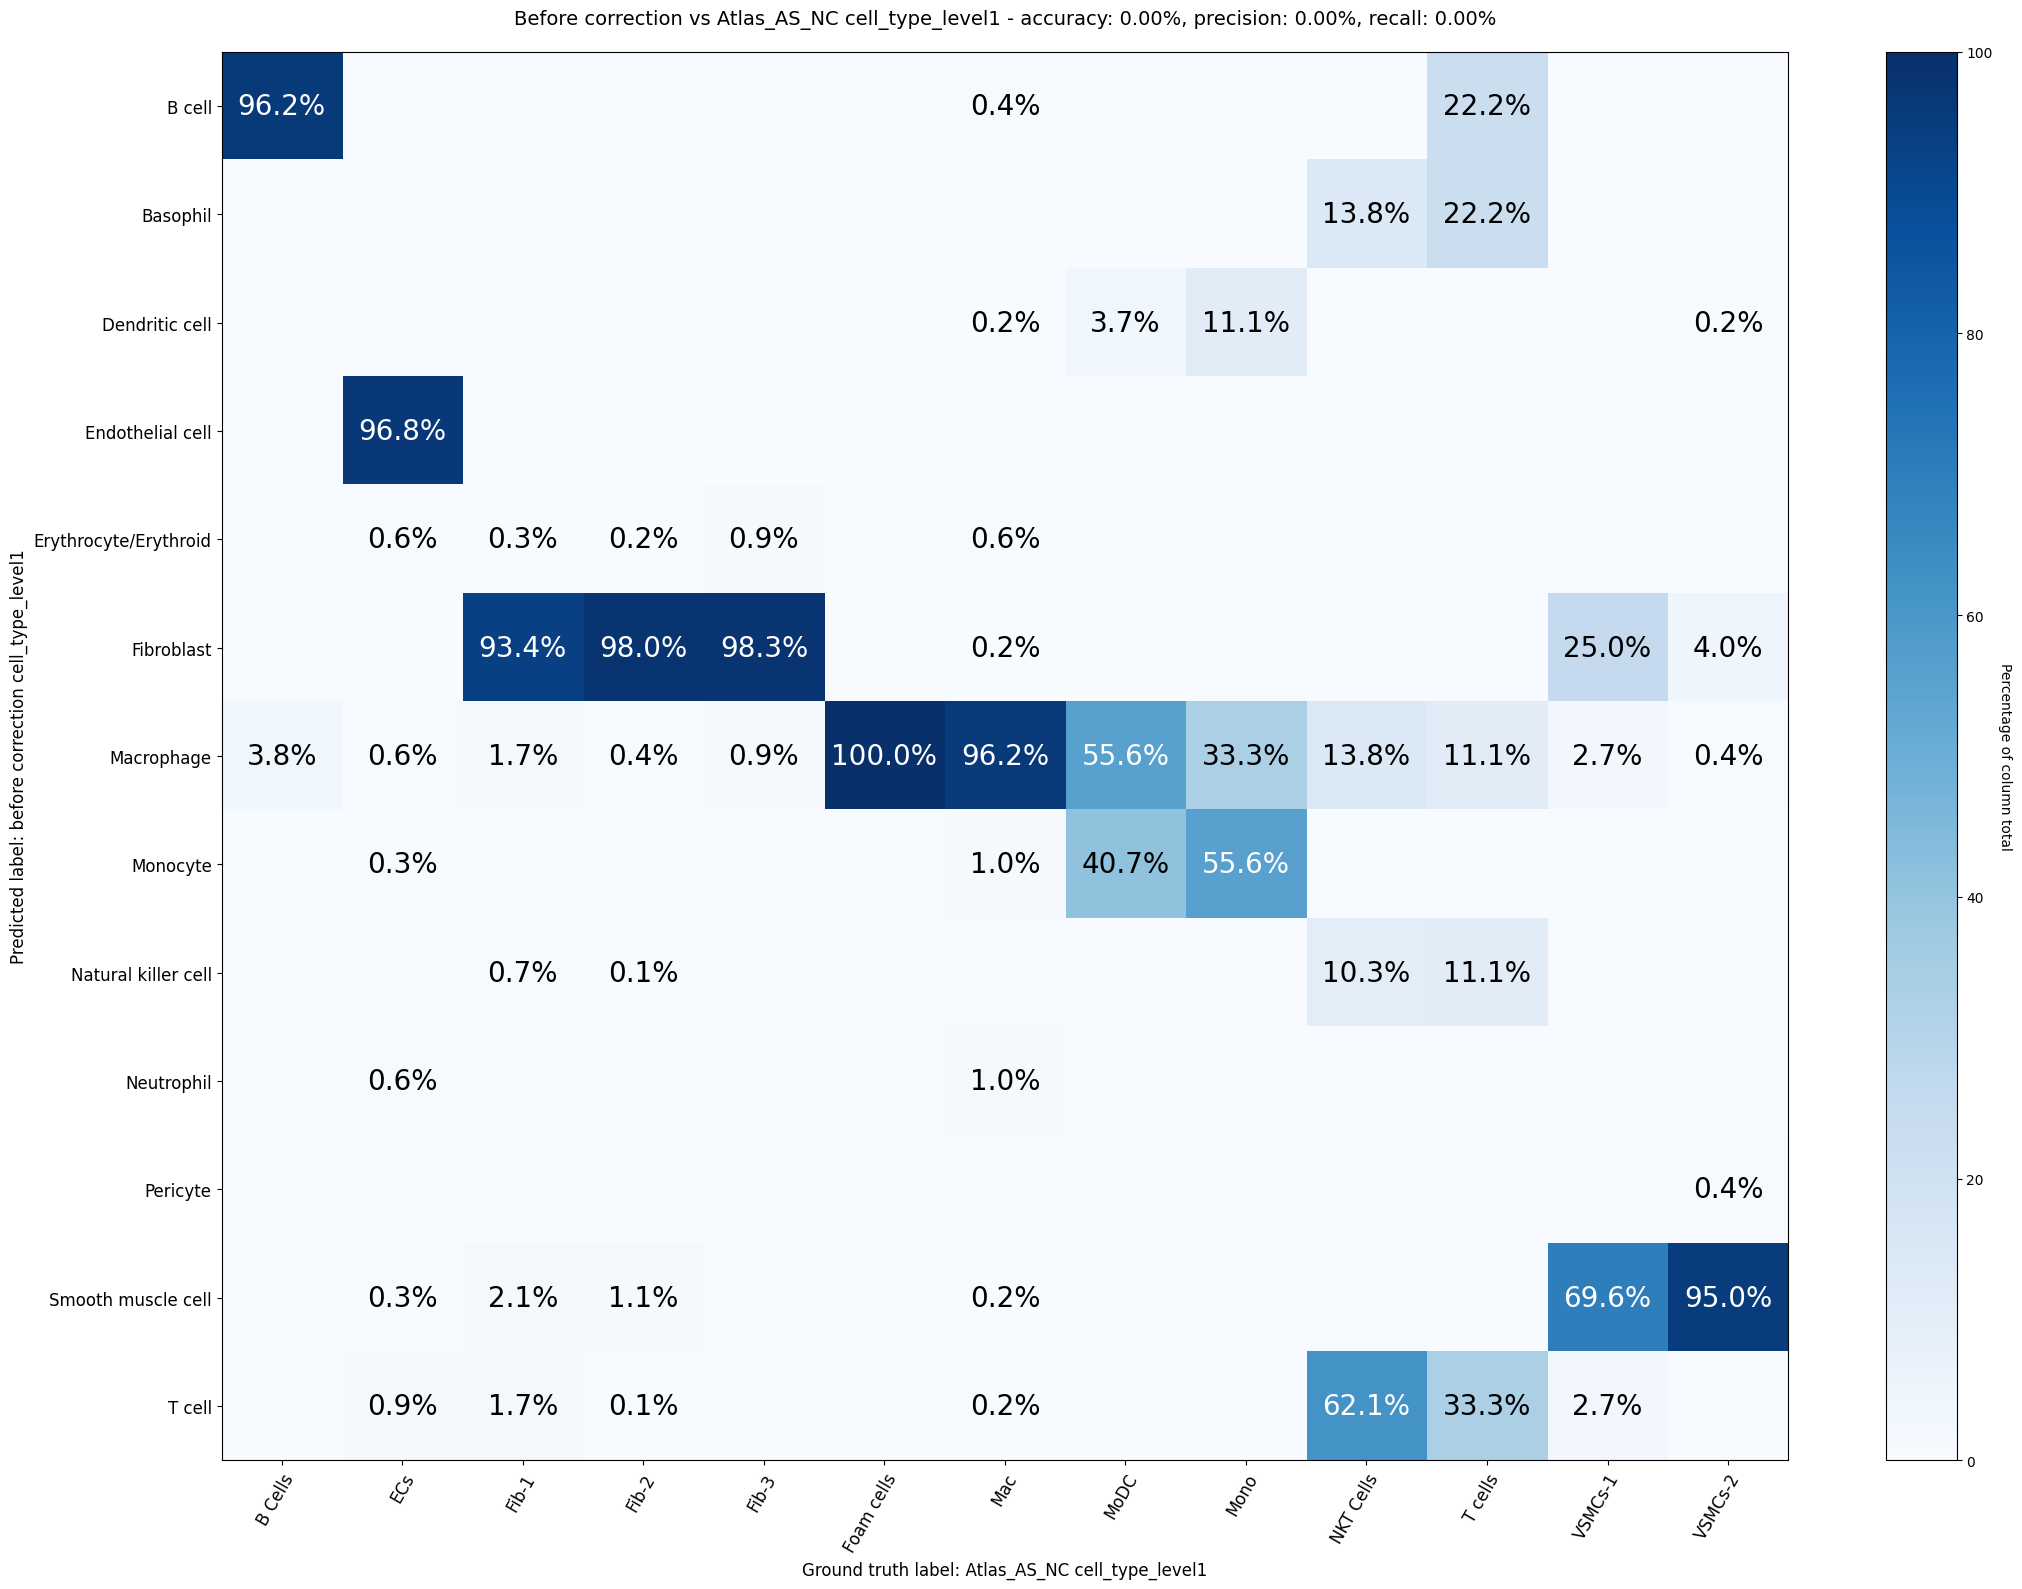


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell        0.0
1                Basophil        0.0
2          Dendritic cell        0.0
3        Endothelial cell        0.0
4   Erythrocyte/Erythroid        0.0
5              Fibroblast        0.0
6              Macrophage        0.0
7                Monocyte        0.0
8     Natural killer cell        0.0
9              Neutrophil        0.0
10               Pericyte        0.0
11     Smooth muscle cell        0.0
12                 T cell        0.0

Per-ground-truth-cell-type recall:
     cell_type  recall
0      B Cells     0.0
1          ECs     0.0
2        Fib-1     0.0
3        Fib-2     0.0
4        Fib-3     0.0
5   Foam cells     0.0
6          Mac     0.0
7         MoDC     0.0
8         Mono     0.0
9    NKT Cells     0.0
10     T cells     0.0
11     VSMCs-1     0.0
12     VSMCs-2     0.0


In [23]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


obs_before=adata.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata.obs_names.copy()
obs_ref=adata_truth.obs[["ground_truth"]].copy()
obs_ref.index=adata_truth.obs_names.copy()

adata.file.close()

# obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

# print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
# print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"ground_truth"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

去除指定细胞类型后共有 561576 个细胞
共同匹配到 2901 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B Cells', 'ECs', 'Fib-1', 'Fib-2', 'Fib-3', 'Foam cells', 'Mac', 'MoDC', 'Mono', 'NKT Cells', 'T cells', 'VSMCs-1', 'VSMCs-2']

Predicted cell types from current adata:
['B cell', 'Basophil', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0000
Weighted precision: 0.0000
Weighted recall: 0.0000

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


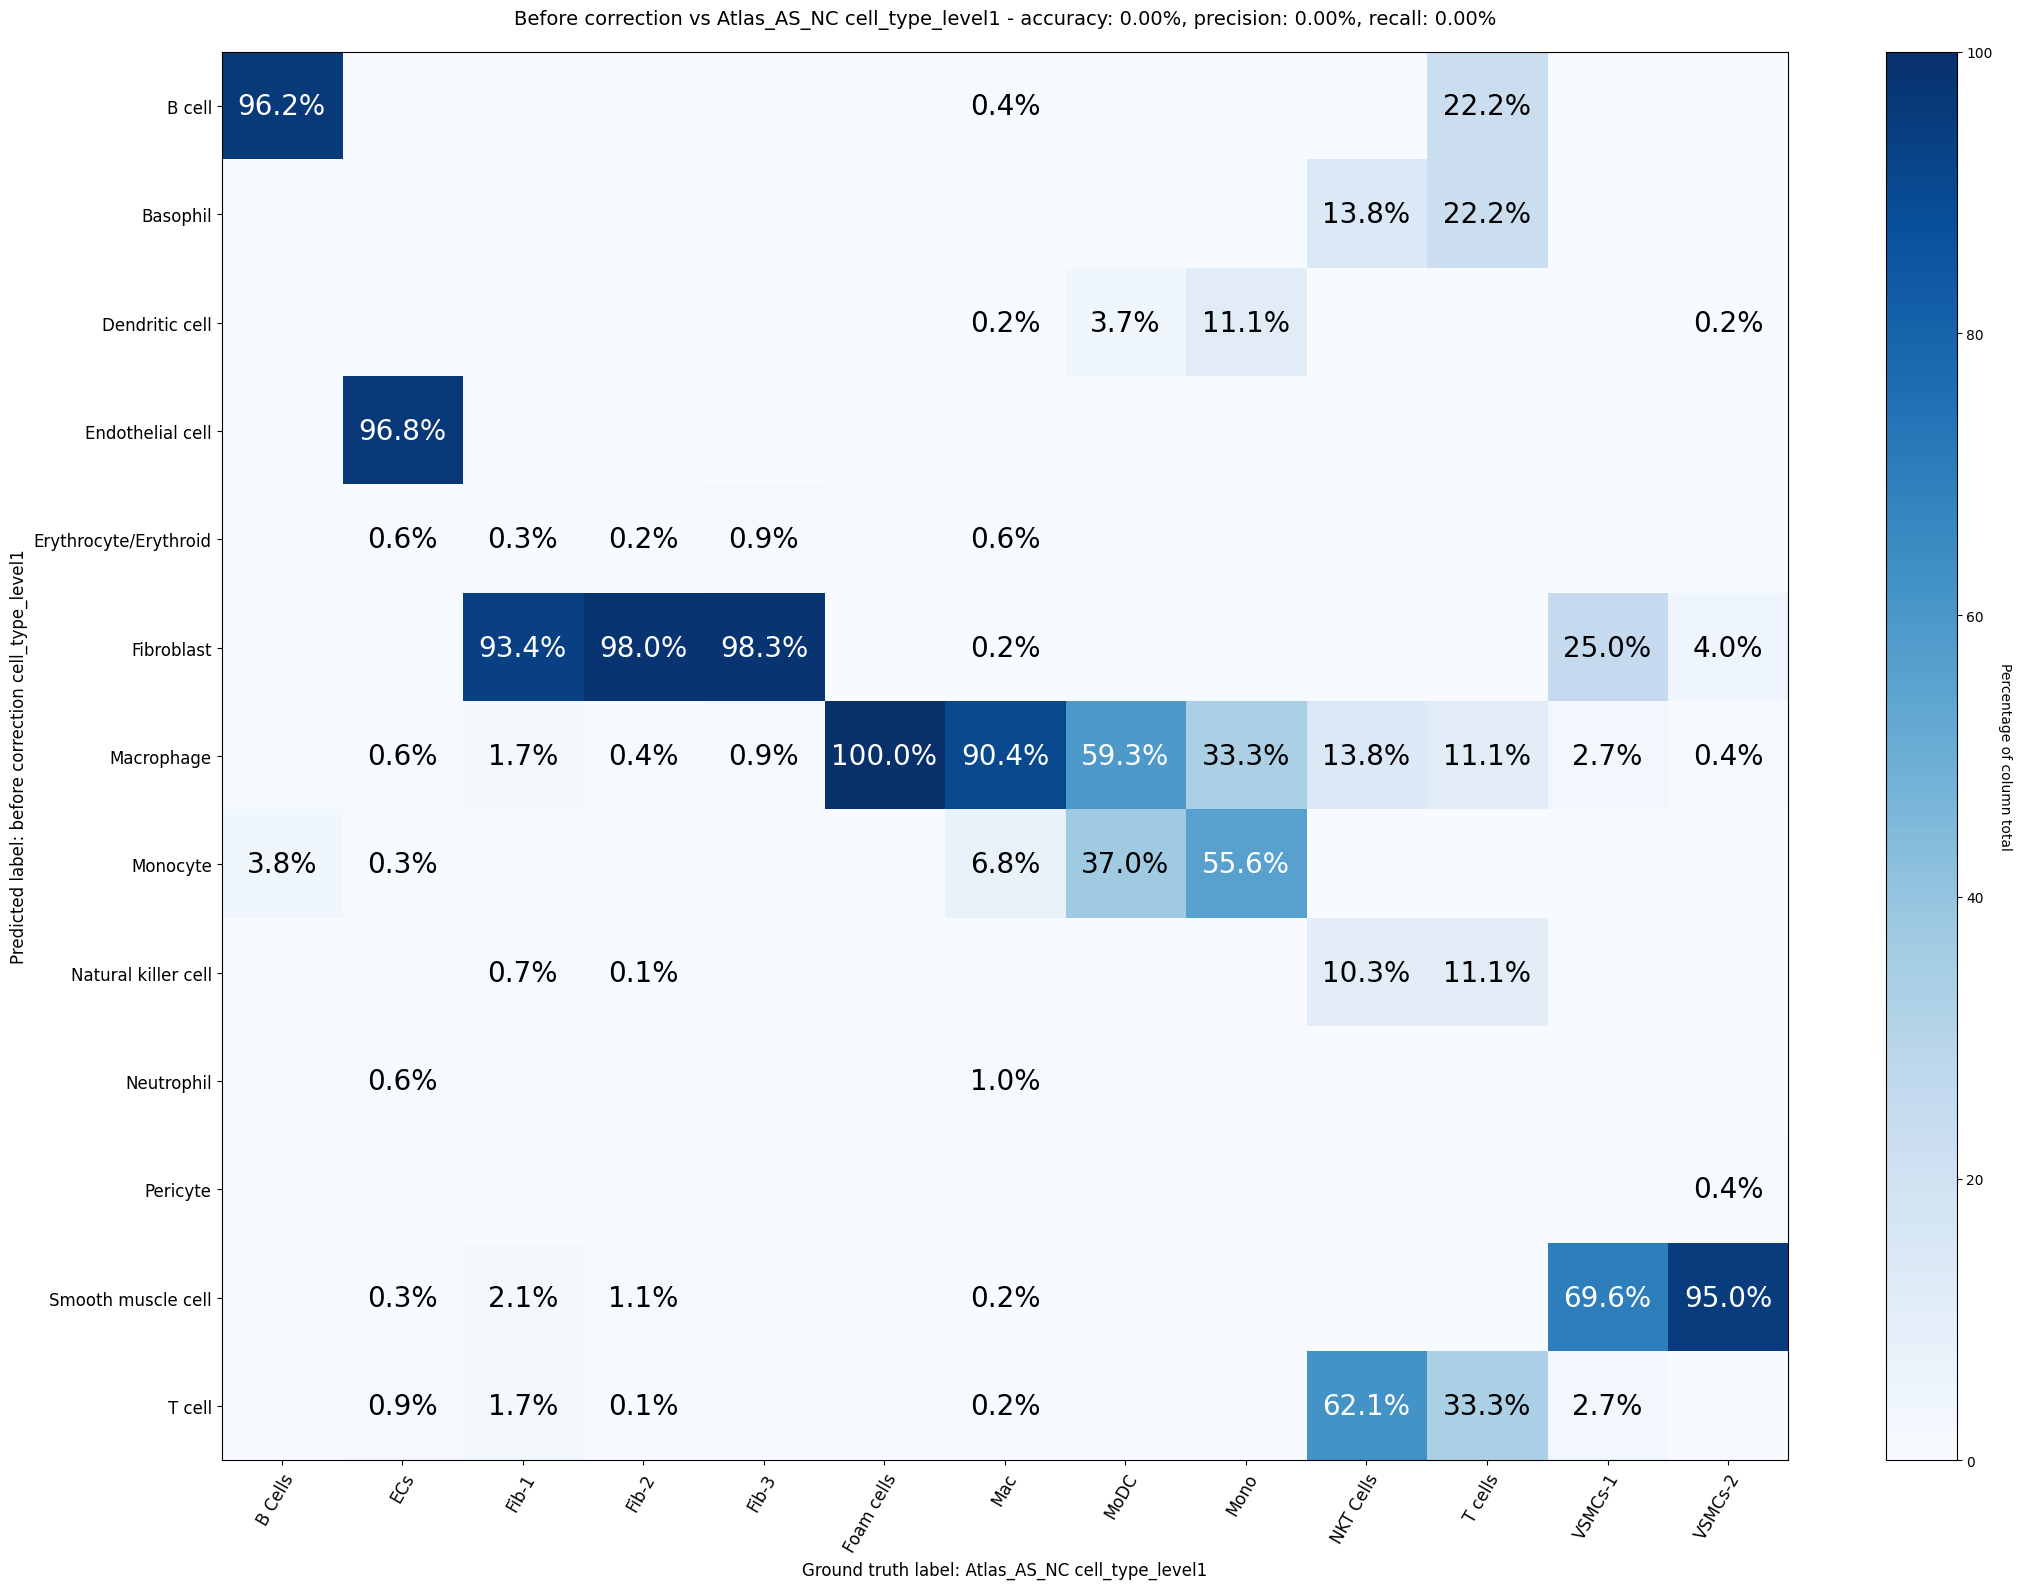


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell        0.0
1                Basophil        0.0
2          Dendritic cell        0.0
3        Endothelial cell        0.0
4   Erythrocyte/Erythroid        0.0
5              Fibroblast        0.0
6              Macrophage        0.0
7                Monocyte        0.0
8     Natural killer cell        0.0
9              Neutrophil        0.0
10               Pericyte        0.0
11     Smooth muscle cell        0.0
12                 T cell        0.0

Per-ground-truth-cell-type recall:
     cell_type  recall
0      B Cells     0.0
1          ECs     0.0
2        Fib-1     0.0
3        Fib-2     0.0
4        Fib-3     0.0
5   Foam cells     0.0
6          Mac     0.0
7         MoDC     0.0
8         Mono     0.0
9    NKT Cells     0.0
10     T cells     0.0
11     VSMCs-1     0.0
12     VSMCs-2     0.0


In [33]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


obs_before=adata.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata.obs_names.copy()
obs_ref=adata_truth.obs[["ground_truth"]].copy()
obs_ref.index=adata_truth.obs_names.copy()

adata.file.close()

# obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

# print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
# print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"ground_truth"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

# umap plot for corrected train

In [13]:
adata_mouse = sc.read_h5ad("./output_mouse_scpoli/work_0513/mouse_scpoli_concat_corrected_all_no_gene.h5ad")
adata_mouse

AnnData object with n_obs × n_vars = 543503 × 10
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'conditions_combined'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [14]:
color_palette_level1 = {
    'T cell': '#3182bd',                       # blue for all T cell types
    'Macrophage': '#8c564b',                   # brown for all macrophages
    'Erythrocyte/Erythroid': '#ff7f0e',                  # vibrant orange
    'Mast cell': '#d62728',                    # red
    'Natural killer cell': '#98df8a',                      # light green
    'Pericyte': '#f7b6d2',                 # pastel pink
    'Smooth muscle cell': '#7b4173',           # deeper purple
    'Fibroblast': '#e377c2',                   # bright pink
    'B cell': '#2ca02c',                       # green
    'Dendritic cell': '#807dba',               # violet for dendritic cells
    'Endothelial cell': '#fdae6b',                           # orange for all endothelial cells  
    'Monocyte': '#c7c7c7',                     # lighter gray
    'Neutrophil': '#17becf',
    'Basophil': '#ac8d62',
    'Reference' : 'white'               # teal
}

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


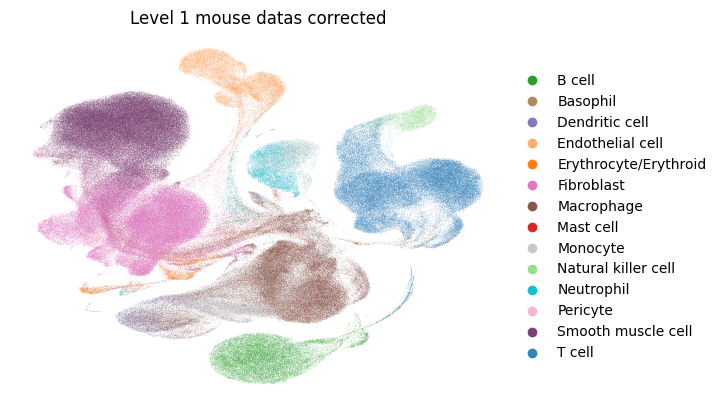

In [18]:
# Plot UMAP with custom color palette
sc.pl.umap(
    adata_mouse,
    color='cell_type_level1_corrected',
    palette=color_palette_level1,
    show=True,
    frameon=False,
    title = "Level 1 mouse datas corrected",
    # save="level1-withReference.pdf"
)

In [19]:
adata_mouse.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
Smooth muscle cell       128121
Fibroblast               123479
Macrophage                96966
T cell                    77043
B cell                    28064
Monocyte                  26707
Endothelial cell          26566
Neutrophil                13235
Erythrocyte/Erythroid      7677
Dendritic cell             7386
Natural killer cell        5676
Pericyte                   1293
Basophil                   1106
Mast cell                   184
Name: count, dtype: int64